In [85]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
warnings.filterwarnings("ignore")

# take a look of ur data actually this small notebook gona trun into 1000s line of code when its is gona replecate on VS >

# data understanding/observation 
df = pd.read_csv("twitter-stocks.csv")

In [86]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-11-07,45.099998,50.090000,44.000000,44.900002,44.900002,117701670.0
1,2013-11-08,45.930000,46.939999,40.685001,41.650002,41.650002,27925307.0
2,2013-11-11,40.500000,43.000000,39.400002,42.900002,42.900002,16113941.0
3,2013-11-12,43.660000,43.779999,41.830002,41.900002,41.900002,6316755.0
4,2013-11-13,41.029999,42.869999,40.759998,42.599998,42.599998,8688325.0
5,2013-11-14,42.340000,45.669998,42.240002,44.689999,44.689999,11099433.0
6,2013-11-15,45.250000,45.270000,43.430000,43.980000,43.980000,8010663.0
7,2013-11-18,43.500000,43.950001,40.849998,41.139999,41.139999,12810624.0
8,2013-11-19,41.389999,41.900002,40.000000,41.750000,41.750000,7436616.0
9,2013-11-20,41.400002,41.750000,40.509998,41.049999,41.049999,5767325.0


In [87]:
df.tail(5)

,Date,Open,High,Low,Close,Adj Close,Volume
2254,2022-10-21,50.000000,50.750000,49.549999,49.889999,49.889999,51209029.0
2255,2022-10-24,50.709999,51.860001,50.520000,51.520000,51.520000,22987553.0
2256,2022-10-25,52.415001,53.180000,52.200001,52.779999,52.779999,35077848.0
2257,2022-10-26,52.950001,53.500000,52.770000,53.349998,53.349998,28064973.0
2258,2022-10-27,53.910000,54.000000,53.700001,53.700001,53.700001,136345128.0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2259 entries, 0 to 2258
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2259 non-null   object 
 1   Open       2259 non-null   float64
 2   High       2259 non-null   float64
 3   Low        2259 non-null   float64
 4   Close      2259 non-null   float64
 5   Adj Close  2259 non-null   float64
 6   Volume     2259 non-null   float64
dtypes: float64(6), object(1)
memory usage: 123.7+ KB


In [89]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2259.000000,2259.000000,2259.000000,2259.000000,2259.000000,2.259000e+03
mean,36.020286,36.699881,35.339465,36.003625,36.003625,2.175186e+07
std,14.118463,14.372057,13.828724,14.089989,14.089989,1.909988e+07
min,13.950000,14.220000,13.725000,14.010000,14.010000,0.000000e+00
25%,25.550000,26.215001,24.912501,25.410000,25.410000,1.233530e+07
50%,35.419998,36.099998,34.820000,35.490002,35.490002,1.691305e+07
75%,44.205000,45.015000,43.327501,44.135000,44.135000,2.428082e+07
max,78.360001,80.750000,76.050003,77.629997,77.629997,2.692131e+08


In [90]:
df.columns


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

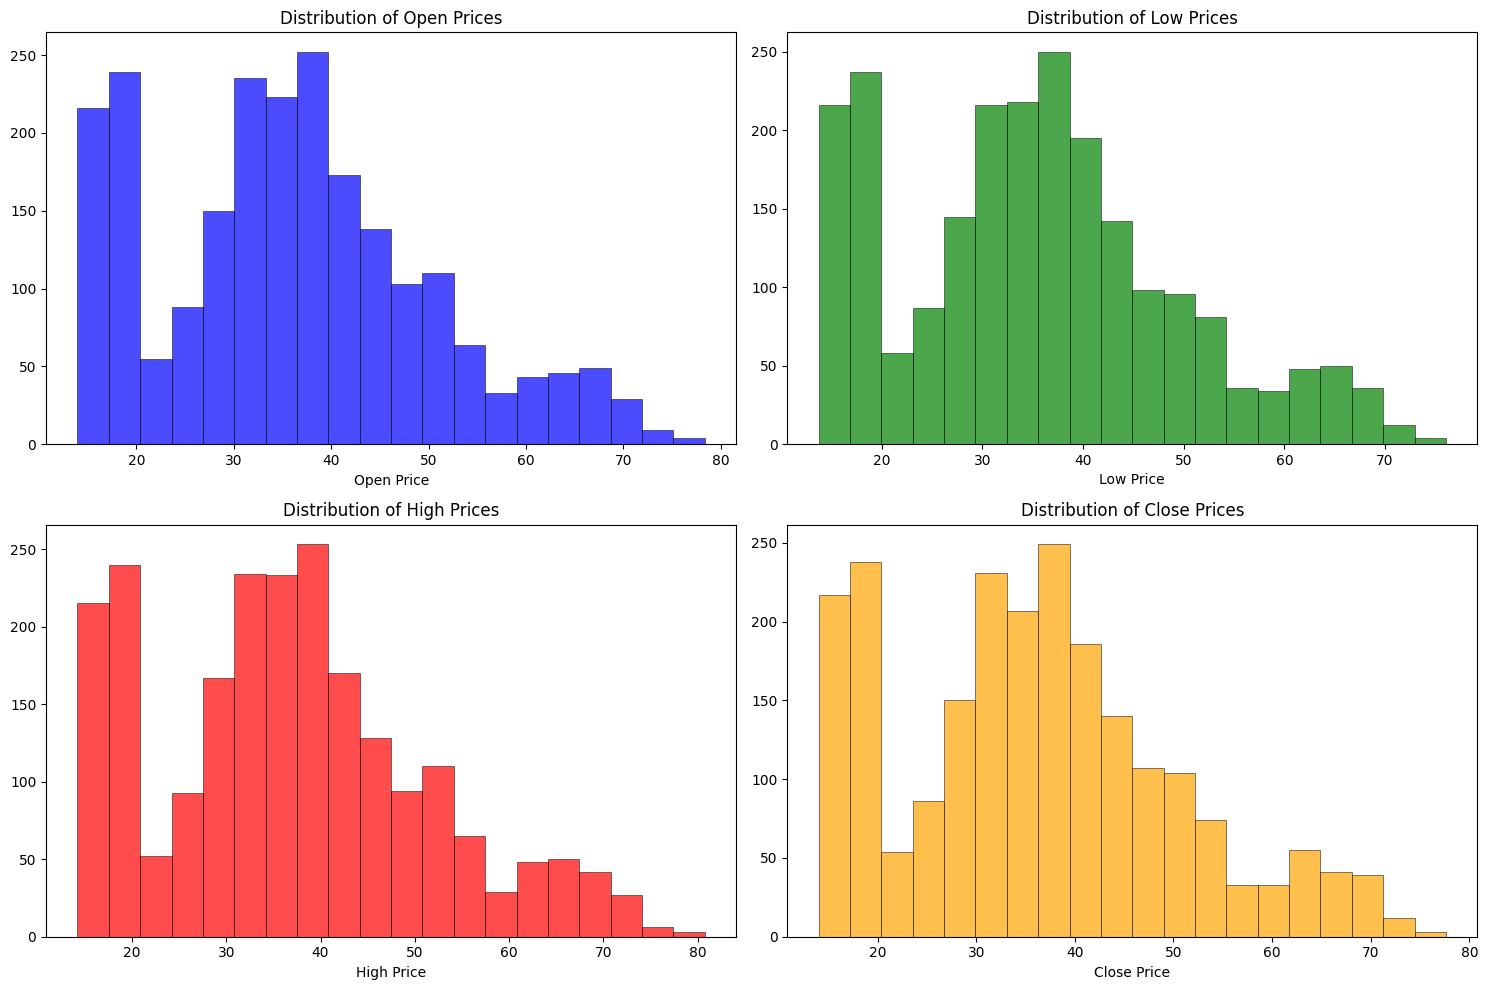

In [91]:
# data visualization
fig , ax = plt.subplots(figsize=(15, 10), nrows=2, ncols=2)
ax[0, 0].hist(df['Open'], bins=20, color='blue', alpha=0.7, linewidth=0.5, edgecolor='black')
ax[0, 0].set_title('Distribution of Open Prices')
ax[0, 0].set_xlabel('Open Price')

ax[0, 1].hist(df['Low'], bins=20, color='green', alpha=0.7, linewidth=0.5, edgecolor='black')
ax[0, 1].set_title('Distribution of Low Prices')
ax[0, 1].set_xlabel('Low Price')

ax[1, 0].hist(df['High'], bins=20, color='red', alpha=0.7, linewidth=0.5, edgecolor='black')
ax[1, 0].set_title('Distribution of High Prices')
ax[1, 0].set_xlabel('High Price')

ax[1, 1].hist(df['Close'], bins=20, color='orange', alpha=0.7, linewidth=0.5, edgecolor='black')
ax[1, 1].set_title('Distribution of Close Prices')
ax[1, 1].set_xlabel('Close Price')

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

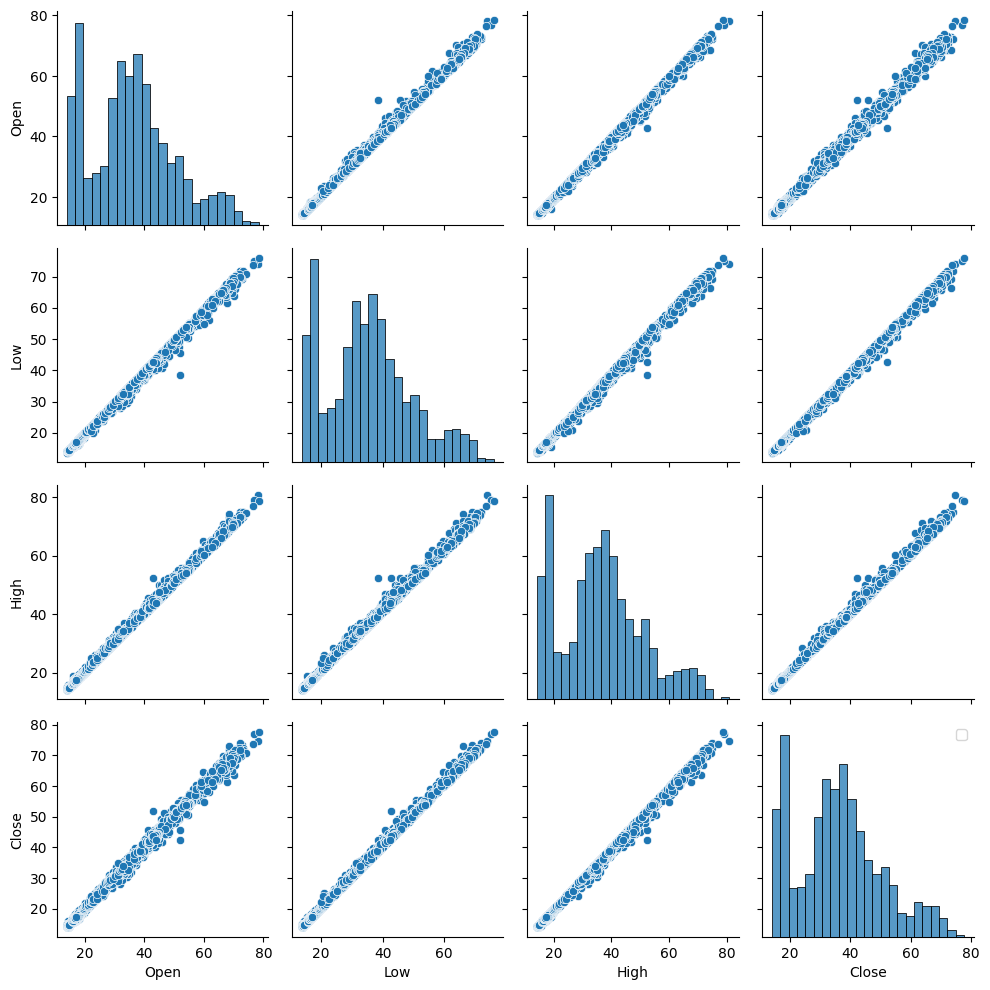

In [92]:
plt.figure(figsize=(15, 10))
sns.pairplot(df[['Open', 'Low', 'High', 'Close']])
plt.tight_layout()
plt.legend()
plt.show()

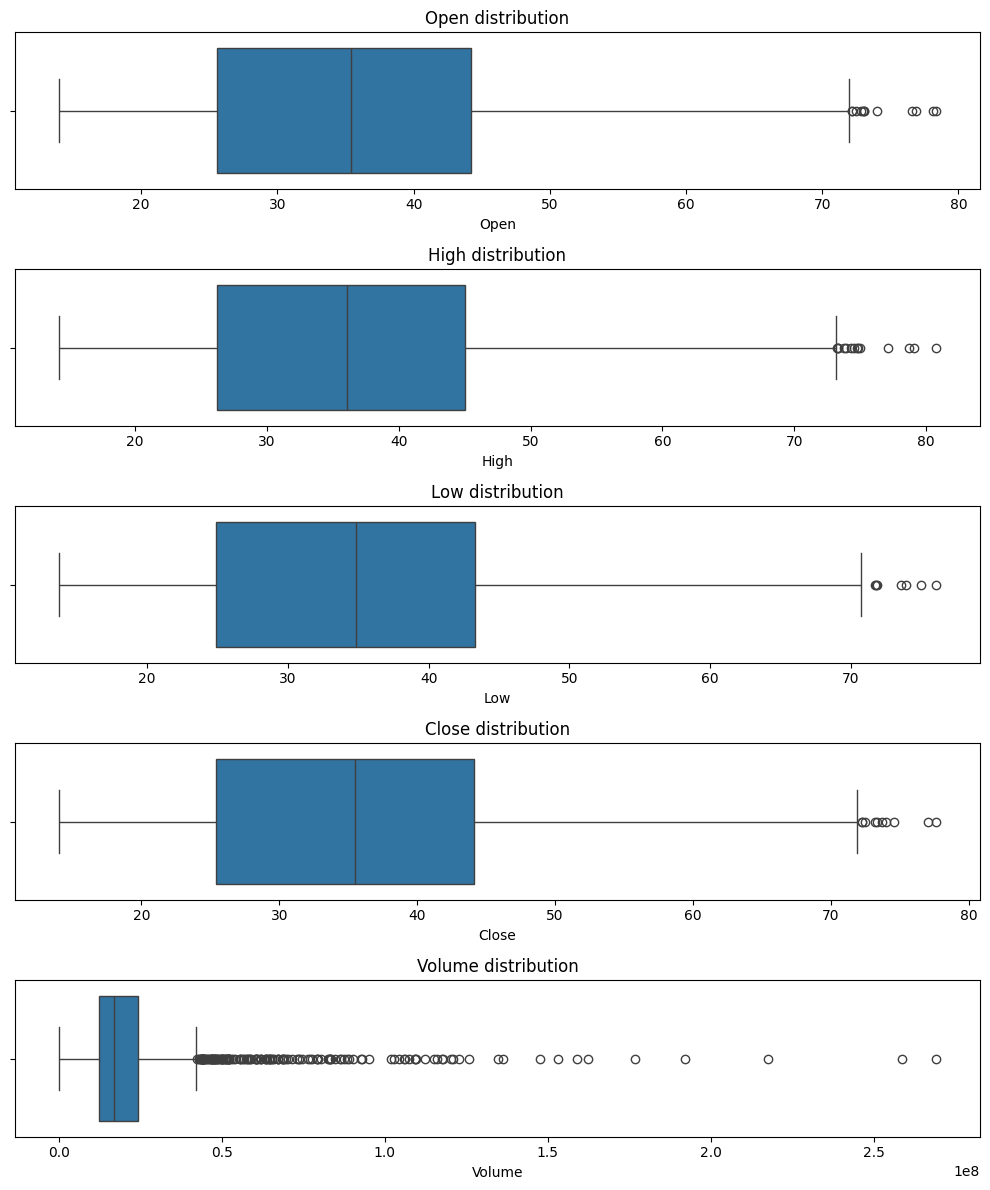

In [93]:
fig, axes = plt.subplots(5, 1, figsize=(10, 12))

for ax, col in zip(axes, ['Open', 'High', 'Low', 'Close', 'Volume']):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f'{col} distribution')

plt.tight_layout()
plt.show()

<Axes: >

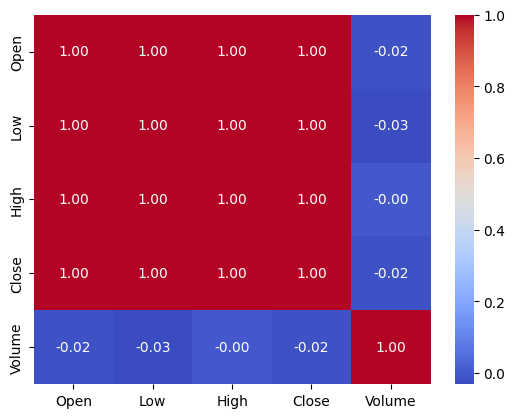

In [96]:
dff = df[['Open', 'Low', 'High', 'Close', 'Volume']]
sns.heatmap(dff.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
df = df.dropna().copy()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').copy()

df['log_volume'] = np.log1p(df['Volume'])

for lag in [1, 2, 3, 5, 10, 20, 60]:
    df[f'volume_lag_{lag}'] = df['log_volume'].shift(lag)
    df[f'return_lag_{lag}'] = df['Close'].pct_change(lag).shift(1)
    df[f'log_close_lag_{lag}'] = np.log(df['Close']).shift(lag)

df['prev_day_range_pct'] = ((df['High'] - df['Low']) / df['Open']).shift(1)
previous_return = df['Close'].pct_change().shift(1)

for window in [3, 5, 10, 20, 60]:
    df[f'volume_mean_{window}'] = df['log_volume'].shift(1).rolling(window).mean()
    df[f'volume_std_{window}'] = df['log_volume'].shift(1).rolling(window).std()
    df[f'return_std_{window}'] = previous_return.rolling(window).std()
    df[f'close_vs_ma_{window}'] = (
        df['Close'].shift(1) / df['Close'].shift(1).rolling(window).mean() - 1
    )

df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month

model_df = df.dropna()

feature_prefixes = (
    'volume_lag_', 'return_lag_', 'log_close_lag_', 'volume_mean_',
    'volume_std_', 'return_std_', 'close_vs_ma_'
)
features = [column for column in df.columns if column.startswith(feature_prefixes)]
features += ['prev_day_range_pct', 'day_of_week', 'month']

X = model_df[features]
y = model_df['log_volume']

split = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model = ExtraTreesRegressor(
    n_estimators=700,
    max_depth=None,
    min_samples_leaf=4,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R2 on log-volume:", r2_score(y_test, pred))

actual_volume = np.expm1(y_test)
pred_volume = np.expm1(pred)
print("MAE in volume:", mean_absolute_error(actual_volume, pred_volume))

R2 on log-volume: 0.4939147340300589
MAE in volume: 9154287.711135741


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1758, 44), (440, 44), (1758,), (440,))

In [ ]:
pred[:5]

array([16.69799212, 16.70310845, 16.61217496, 16.58673716, 16.48839693])